<a href="https://colab.research.google.com/github/sarkarshrayan2-max/surface-scan-mlops/blob/main/notebooks/03_transfer_learning_mlflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path
import os
import subprocess
PROJECT_ROOT = Path("/content/surface-scan-mlops")
if not PROJECT_ROOT.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/sarkarshrayan2-max/surface-scan-mlops.git",
        ],
        check=True,
    )
os.chdir(PROJECT_ROOT)
print("Current folder:", Path.cwd())
print("Project exists:", PROJECT_ROOT.exists())

Current folder: /content/surface-scan-mlops
Project exists: True


In [4]:
!pip -q install "mlflow>=3.0,<4.0" "cryptography>=49,<50"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264

In [5]:
!find "/content/drive/MyDrive/surface-scan-mlops/baseline_cnn" -maxdepth 2 -type d | sort

/content/drive/MyDrive/surface-scan-mlops/baseline_cnn
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/artifacts
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/artifacts/baseline_cnn
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/artifacts/baseline_cnn_regularized
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/mlartifacts
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/mlartifacts/838171caf9c24245b6c9927f47eff598
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/mlartifacts/90f1e774dd8d465ea90e39897b673bb2
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/reports
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/reports/baseline_cnn
/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/reports/baseline_cnn_regularized


In [6]:
!ls -lh "/content/drive/MyDrive/surface-scan-mlops/baseline_cnn/mlflow.db"

-rw------- 1 root root 308K Jul  7 21:11 /content/drive/MyDrive/surface-scan-mlops/baseline_cnn/mlflow.db


In [7]:
import shutil
from pathlib import Path

backup_root = Path("/content/drive/MyDrive/surface-scan-mlops/baseline_cnn")

# Restore MLflow database
shutil.copy2(
    backup_root / "mlflow.db",
    "/content/mlflow.db",
)

# Restore MLflow artifacts
artifact_target = Path("/content/mlartifacts")

if artifact_target.exists():
    shutil.rmtree(artifact_target)

shutil.copytree(
    backup_root / "mlartifacts",
    artifact_target,
)

print("MLflow database restored:", Path("/content/mlflow.db").exists())
print("MLflow artifacts restored:", artifact_target.exists())

MLflow database restored: True
MLflow artifacts restored: True


In [8]:
import mlflow
import mlflow.tensorflow

mlflow.set_tracking_uri("sqlite:////content/mlflow.db")

experiment_name = "surface-defect-classification"
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment is None:
    raise RuntimeError("Previous MLflow experiment was not found.")

mlflow.set_experiment(experiment_name)
mlflow.tensorflow.autolog(disable=True)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    output_format="pandas",
)

print("Experiment:", experiment.name)
print("Previous runs found:", len(runs))
print(runs[["tags.mlflow.runName", "status"]])

2026/07/07 22:56:32 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/07 22:56:32 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


Experiment: surface-defect-classification
Previous runs found: 2
                 tags.mlflow.runName    status
0  custom-cnn-lr-0.0001-dropout-0.50  FINISHED
1   custom-cnn-lr-0.001-dropout-0.40  FINISHED


In [9]:
import shutil
from pathlib import Path

source = Path(
    "/content/drive/MyDrive/surface-scan-mlops/data_understanding/interim"
)
target = Path("data/interim")

if target.exists():
    shutil.rmtree(target)

shutil.copytree(source, target)

print("Restored files:")
for path in sorted(target.rglob("*")):
    if path.is_file():
        print(path)

Restored files:
data/interim/excluded_duplicates.csv
data/interim/splits/test.csv
data/interim/splits/train.csv
data/interim/splits/validation.csv


In [10]:
!test -f ~/.kaggle/kaggle.json && echo "Kaggle credential found" || echo "Kaggle credential missing"

Kaggle credential missing


In [11]:
from google.colab import files

uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))

Saving kaggle (3).json to kaggle (3).json
Uploaded: ['kaggle (3).json']


In [12]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

uploaded_filename = next(iter(uploaded))

with open("/root/.kaggle/kaggle.json", "wb") as file:
    file.write(uploaded[uploaded_filename])

os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle credential configured.")

Kaggle credential configured.


In [13]:
!kaggle datasets download \
  -d kaustubhdikshit/neu-surface-defect-database \
  -p data/raw \
  --unzip

Dataset URL: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database
License(s): unknown
100% 26.4M/26.4M [00:00<00:00, 152MB/s] 



In [14]:
!unzip -q -o data/raw/neu-surface-defect-database.zip -d data/raw

unzip:  cannot find or open data/raw/neu-surface-defect-database.zip, data/raw/neu-surface-defect-database.zip.zip or data/raw/neu-surface-defect-database.zip.ZIP.


In [15]:
!find data/raw -maxdepth 3 -type d | sort

data/raw
data/raw/NEU-DET
data/raw/NEU-DET/train
data/raw/NEU-DET/train/annotations
data/raw/NEU-DET/train/images
data/raw/NEU-DET/validation
data/raw/NEU-DET/validation/annotations
data/raw/NEU-DET/validation/images


In [16]:
from pathlib import Path
required_paths = [
    Path("data/raw/NEU-DET/train/images"),
    Path("data/raw/NEU-DET/validation/images"),
    Path("data/interim/splits/train.csv"),
    Path("data/interim/splits/validation.csv"),
    Path("data/interim/splits/test.csv"),
]

for path in required_paths:
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{path}: {status}")

data/raw/NEU-DET/train/images: FOUND
data/raw/NEU-DET/validation/images: FOUND
data/interim/splits/train.csv: FOUND
data/interim/splits/validation.csv: FOUND
data/interim/splits/test.csv: FOUND


In [17]:
import pandas as pd

split_dir = Path("data/interim/splits")

train_df = pd.read_csv(split_dir / "train.csv")
validation_df = pd.read_csv(split_dir / "validation.csv")
test_df = pd.read_csv(split_dir / "test.csv")
class_names = sorted(train_df["label"].unique())
class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}
print("Classes:", class_names)
print("Class mapping:", class_to_index)
print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Class mapping: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
Train: 1223
Validation: 216
Test: 360


In [18]:
import tensorflow as tf

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def load_transfer_image(image_path, label):
    image_bytes = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image_bytes, channels=3)

    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label


def make_transfer_dataset(dataframe, training=False):
    image_paths = dataframe["path"].astype(str).to_numpy()
    labels = dataframe["label"].map(class_to_index).to_numpy(dtype="int32")

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        load_transfer_image,
        num_parallel_calls=AUTOTUNE,
    )

    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_transfer_dataset(train_df, training=True)
validation_ds = make_transfer_dataset(validation_df)
test_ds = make_transfer_dataset(test_df)

images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0


In [19]:
tf.keras.backend.clear_session()

NUM_CLASSES = len(class_names)

MOBILENET_RUN_NAME = "mobilenetv3small-frozen-lr-0.001"
MOBILENET_LEARNING_RATE = 0.001

mobilenet_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal_and_vertical",
            seed=SEED,
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.05,
            width_factor=0.05,
            seed=SEED,
        ),
    ],
    name="mobilenet_augmentation",
)

mobilenet_base = tf.keras.applications.MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

mobilenet_base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3), name="image")

x = mobilenet_augmentation(inputs)
x = mobilenet_base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dropout(0.30, name="dropout")(x)
outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="defect_classifier",
)(x)
mobilenet_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="mobilenetv3small_transfer_frozen",
)
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=MOBILENET_LEARNING_RATE
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)
mobilenet_model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv3small_transfer_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_augmentation          │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ defect_classifier (Dense)       │ (None, 6)              │         3,462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 942,582 (3.60 MB)

 Trainable params: 3,462 (13.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [20]:
from pathlib import Path

MOBILENET_EPOCHS = 20
MOBILENET_PATIENCE = 5

mobilenet_artifact_dir = Path("artifacts/mobilenetv3small")
mobilenet_artifact_dir.mkdir(parents=True, exist_ok=True)

mobilenet_frozen_model_path = (
    mobilenet_artifact_dir / "mobilenetv3small_frozen_best.keras"
)
mobilenet_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=MOBILENET_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=mobilenet_frozen_model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("Run name:", MOBILENET_RUN_NAME)
print("Epoch limit:", MOBILENET_EPOCHS)
print("Best model path:", mobilenet_frozen_model_path)

Run name: mobilenetv3small-frozen-lr-0.001
Epoch limit: 20
Best model path: artifacts/mobilenetv3small/mobilenetv3small_frozen_best.keras


In [21]:
import mlflow
import numpy as np

with mlflow.start_run(run_name=MOBILENET_RUN_NAME) as run:
    mobilenet_run_id = run.info.run_id

    mlflow.set_tags(
        {
            "experiment_phase": "transfer_learning",
            "training_stage": "frozen_backbone",
        }
    )

    mlflow.log_params(
        {
            "model_name": "MobileNetV3Small",
            "base_weights": "imagenet",
            "backbone_trainable": False,
            "image_height": IMAGE_SIZE[0],
            "image_width": IMAGE_SIZE[1],
            "batch_size": BATCH_SIZE,
            "learning_rate": MOBILENET_LEARNING_RATE,
            "epochs_limit": MOBILENET_EPOCHS,
            "early_stopping_patience": MOBILENET_PATIENCE,
            "dropout": 0.30,
            "optimizer": "Adam",
            "train_images": len(train_df),
            "validation_images": len(validation_df),
            "num_classes": NUM_CLASSES,
        }
    )

    mobilenet_history = mobilenet_model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=MOBILENET_EPOCHS,
        callbacks=mobilenet_callbacks,
        verbose=1,
    )

    for epoch_index in range(len(mobilenet_history.history["loss"])):
        mlflow.log_metrics(
            {
                "train_loss": float(
                    mobilenet_history.history["loss"][epoch_index]
                ),
                "train_accuracy": float(
                    mobilenet_history.history["accuracy"][epoch_index]
                ),
                "val_loss": float(
                    mobilenet_history.history["val_loss"][epoch_index]
                ),
                "val_accuracy": float(
                    mobilenet_history.history["val_accuracy"][epoch_index]
                ),
            },
            step=epoch_index + 1,
        )

    best_epoch_index = int(
        np.argmin(mobilenet_history.history["val_loss"])
    )

    mlflow.log_metrics(
        {
            "best_epoch": best_epoch_index + 1,
            "best_val_loss": float(
                mobilenet_history.history["val_loss"][best_epoch_index]
            ),
            "best_val_accuracy": float(
                mobilenet_history.history["val_accuracy"][best_epoch_index]
            ),
        }
    )

    mlflow.log_artifact(
        str(mobilenet_frozen_model_path),
        artifact_path="keras_model",
    )

print("Frozen MobileNetV3Small training completed.")
print("MLflow run ID:", mobilenet_run_id)
print("Best checkpoint:", mobilenet_frozen_model_path)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3562 - loss: 1.6912
Epoch 1: val_loss improved from None to 0.82444, saving model to artifacts/mobilenetv3small/mobilenetv3small_frozen_best.keras

Epoch 1: finished saving model to artifacts/mobilenetv3small/mobilenetv3small_frozen_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - accuracy: 0.5348 - loss: 1.3955 - val_accuracy: 0.9398 - val_loss: 0.8244 - learning_rate: 0.0010
Epoch 2/20
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8616 - loss: 0.7917
Epoch 2: val_loss improved from 0.82444 to 0.42911, saving model to artifacts/mobilenetv3small/mobilenetv3small_frozen_best.keras

Epoch 2: finished saving model to artifacts/mobilenetv3small/mobilenetv3small_frozen_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9011 - loss: 0.6727 - val_accuracy: 0.9630 - val_loss: 0.4291 - learning_rate: 0.0010
Epoch 3/20
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9552 - loss: 0.4435
Epoch 3: val

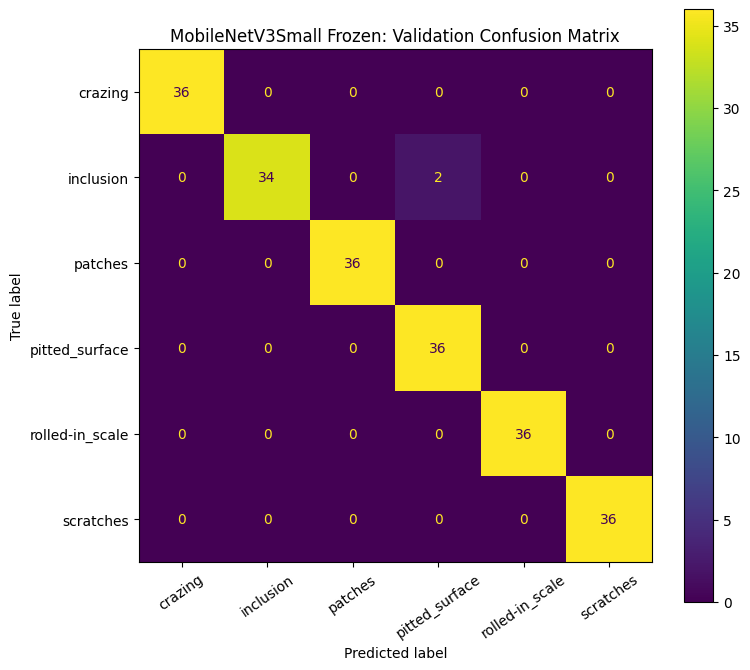

Validation metrics:
validation_accuracy: 0.9907
validation_macro_precision: 0.9912
validation_macro_recall: 0.9907
validation_macro_f1: 0.9907

Logged to MLflow run: 99180984018245b9b1ced1f57a9f27ef


In [22]:
import json

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

# Predict on validation
validation_probabilities_mobilenet = mobilenet_model.predict(
    validation_ds,
    verbose=0,
)

y_pred_mobilenet = np.argmax(
    validation_probabilities_mobilenet,
    axis=1,
)

y_true_mobilenet = np.concatenate(
    [
        batch_labels.numpy()
        for _, batch_labels in validation_ds
    ],
    axis=0,
)

mobilenet_metrics = {
    "validation_accuracy": float(
        accuracy_score(y_true_mobilenet, y_pred_mobilenet)
    ),
    "validation_macro_precision": float(
        precision_score(
            y_true_mobilenet,
            y_pred_mobilenet,
            average="macro",
            zero_division=0,
        )
    ),
    "validation_macro_recall": float(
        recall_score(
            y_true_mobilenet,
            y_pred_mobilenet,
            average="macro",
            zero_division=0,
        )
    ),
    "validation_macro_f1": float(
        f1_score(
            y_true_mobilenet,
            y_pred_mobilenet,
            average="macro",
            zero_division=0,
        )
    ),
}

report_dir = Path("reports/mobilenetv3small")
report_dir.mkdir(parents=True, exist_ok=True)

with open(report_dir / "validation_metrics.json", "w") as file:
    json.dump(mobilenet_metrics, file, indent=2)

classification_report_mobilenet = classification_report(
    y_true_mobilenet,
    y_pred_mobilenet,
    target_names=class_names,
    zero_division=0,
    output_dict=True,
)

with open(report_dir / "classification_report.json", "w") as file:
    json.dump(classification_report_mobilenet, file, indent=2)

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_true_mobilenet,
    y_pred_mobilenet,
    display_labels=class_names,
    xticks_rotation=35,
    ax=ax,
)

plt.title("MobileNetV3Small Frozen: Validation Confusion Matrix")
plt.tight_layout()

confusion_matrix_path = report_dir / "validation_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=160)
plt.show()

with mlflow.start_run(run_id=mobilenet_run_id):
    mlflow.log_metrics(mobilenet_metrics)
    mlflow.log_artifact(
        str(report_dir / "validation_metrics.json"),
        artifact_path="evaluation",
    )
    mlflow.log_artifact(
        str(report_dir / "classification_report.json"),
        artifact_path="evaluation",
    )
    mlflow.log_artifact(
        str(confusion_matrix_path),
        artifact_path="evaluation",
    )

print("Validation metrics:")
for metric_name, metric_value in mobilenet_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

print("\nLogged to MLflow run:", mobilenet_run_id)

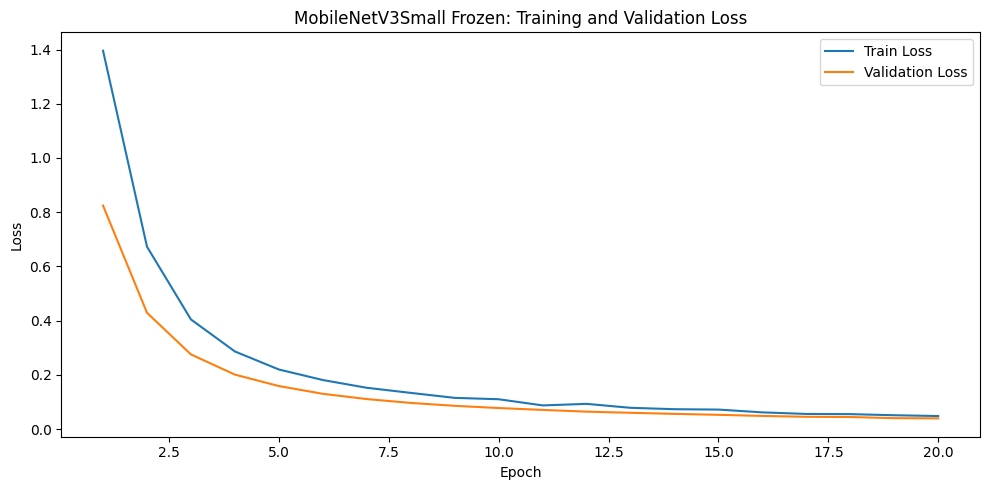

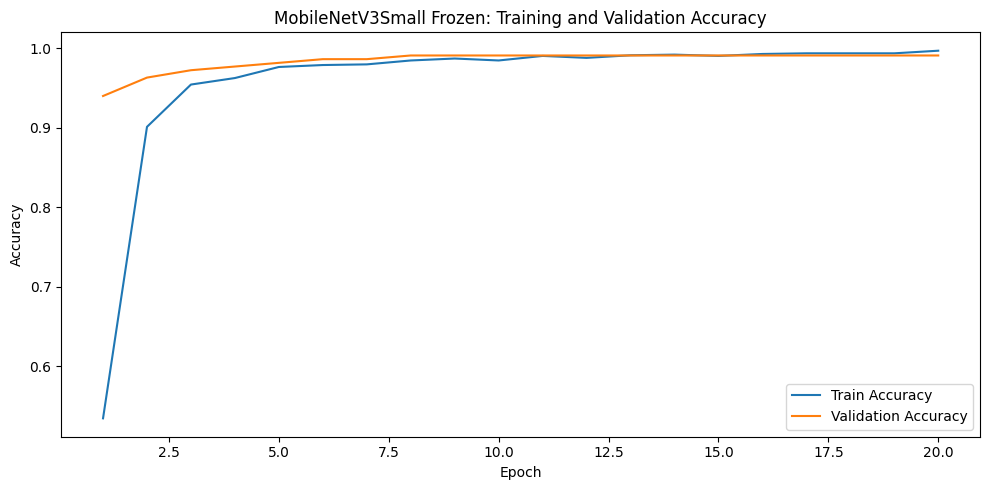

MobileNetV3Small training curves saved and logged to MLflow.


In [23]:
report_dir = Path("reports/mobilenetv3small")
report_dir.mkdir(parents=True, exist_ok=True)

epochs_ran = range(1, len(mobilenet_history.history["loss"]) + 1)

# Loss curve
plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, mobilenet_history.history["loss"], label="Train Loss")
plt.plot(epochs_ran, mobilenet_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV3Small Frozen: Training and Validation Loss")
plt.legend()
plt.tight_layout()

loss_curve_path = report_dir / "loss_curve.png"
plt.savefig(loss_curve_path, dpi=160)
plt.show()

# Accuracy curve
plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, mobilenet_history.history["accuracy"], label="Train Accuracy")
plt.plot(epochs_ran, mobilenet_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV3Small Frozen: Training and Validation Accuracy")
plt.legend()
plt.tight_layout()

accuracy_curve_path = report_dir / "accuracy_curve.png"
plt.savefig(accuracy_curve_path, dpi=160)
plt.show()

with mlflow.start_run(run_id=mobilenet_run_id):
    mlflow.log_artifact(str(loss_curve_path), artifact_path="training_curves")
    mlflow.log_artifact(str(accuracy_curve_path), artifact_path="training_curves")

print("MobileNetV3Small training curves saved and logged to MLflow.")

In [24]:
tf.keras.backend.clear_session()

EFFICIENTNET_RUN_NAME = "efficientnetb0-frozen-lr-0.001"
EFFICIENTNET_LEARNING_RATE = 0.001

efficientnet_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal_and_vertical",
            seed=SEED,
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.05,
            width_factor=0.05,
            seed=SEED,
        ),
    ],
    name="efficientnet_augmentation",
)

efficientnet_base = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

efficientnet_base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3), name="image")

x = efficientnet_augmentation(inputs)
x = efficientnet_base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = tf.keras.layers.Dropout(0.30, name="dropout")(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="defect_classifier",
)(x)

efficientnet_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="efficientnetb0_transfer_frozen",
)

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=EFFICIENTNET_LEARNING_RATE
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb0_transfer_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnet_augmentation       │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ defect_classifier (Dense)       │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [25]:
EFFICIENTNET_EPOCHS = 20
EFFICIENTNET_PATIENCE = 5

efficientnet_artifact_dir = Path("artifacts/efficientnetb0")
efficientnet_artifact_dir.mkdir(parents=True, exist_ok=True)

efficientnet_model_path = (
    efficientnet_artifact_dir / "efficientnetb0_frozen_best.keras"
)

efficientnet_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EFFICIENTNET_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=efficientnet_model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("Run name:", EFFICIENTNET_RUN_NAME)
print("Epoch limit:", EFFICIENTNET_EPOCHS)
print("Best model path:", efficientnet_model_path)

Run name: efficientnetb0-frozen-lr-0.001
Epoch limit: 20
Best model path: artifacts/efficientnetb0/efficientnetb0_frozen_best.keras


In [26]:
with mlflow.start_run(run_name=EFFICIENTNET_RUN_NAME) as run:
    efficientnet_run_id = run.info.run_id

    mlflow.set_tags(
        {
            "experiment_phase": "transfer_learning",
            "training_stage": "frozen_backbone",
        }
    )

    mlflow.log_params(
        {
            "model_name": "EfficientNetB0",
            "base_weights": "imagenet",
            "backbone_trainable": False,
            "image_height": IMAGE_SIZE[0],
            "image_width": IMAGE_SIZE[1],
            "batch_size": BATCH_SIZE,
            "learning_rate": EFFICIENTNET_LEARNING_RATE,
            "epochs_limit": EFFICIENTNET_EPOCHS,
            "early_stopping_patience": EFFICIENTNET_PATIENCE,
            "dropout": 0.30,
            "optimizer": "Adam",
            "train_images": len(train_df),
            "validation_images": len(validation_df),
            "num_classes": NUM_CLASSES,
        }
    )

    efficientnet_history = efficientnet_model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=EFFICIENTNET_EPOCHS,
        callbacks=efficientnet_callbacks,
        verbose=1,
    )

    for epoch_index in range(len(efficientnet_history.history["loss"])):
        mlflow.log_metrics(
            {
                "train_loss": float(
                    efficientnet_history.history["loss"][epoch_index]
                ),
                "train_accuracy": float(
                    efficientnet_history.history["accuracy"][epoch_index]
                ),
                "val_loss": float(
                    efficientnet_history.history["val_loss"][epoch_index]
                ),
                "val_accuracy": float(
                    efficientnet_history.history["val_accuracy"][epoch_index]
                ),
            },
            step=epoch_index + 1,
        )

    best_epoch_index = int(
        np.argmin(efficientnet_history.history["val_loss"])
    )

    mlflow.log_metrics(
        {
            "best_epoch": best_epoch_index + 1,
            "best_val_loss": float(
                efficientnet_history.history["val_loss"][best_epoch_index]
            ),
            "best_val_accuracy": float(
                efficientnet_history.history["val_accuracy"][best_epoch_index]
            ),
        }
    )

    mlflow.log_artifact(
        str(efficientnet_model_path),
        artifact_path="keras_model",
    )

print("Frozen EfficientNetB0 training completed.")
print("MLflow run ID:", efficientnet_run_id)
print("Best checkpoint:", efficientnet_model_path)

Epoch 1/20
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.4515 - loss: 1.5291
Epoch 1: val_loss improved from None to 0.63987, saving model to artifacts/efficientnetb0/efficientnetb0_frozen_best.keras

Epoch 1: finished saving model to artifacts/efficientnetb0/efficientnetb0_frozen_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 263ms/step - accuracy: 0.6607 - loss: 1.2067 - val_accuracy: 0.9398 - val_loss: 0.6399 - learning_rate: 0.0010
Epoch 2/20
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9298 - loss: 0.5684
Epoch 2: val_loss improved from 0.63987 to 0.32926, saving model to artifacts/efficientnetb0/efficientnetb0_frozen_best.keras

Epoch 2: finished saving model to artifacts/efficientnetb0/efficientnetb0_frozen_best.keras
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - accuracy: 0.9436 - loss: 0.4961 - val_accuracy: 0.9769 - val_loss: 0.3293 - learning_rate: 0.0010
Epoch 3/20
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9655 - loss: 0.3205
Epoch 3: val_loss improved

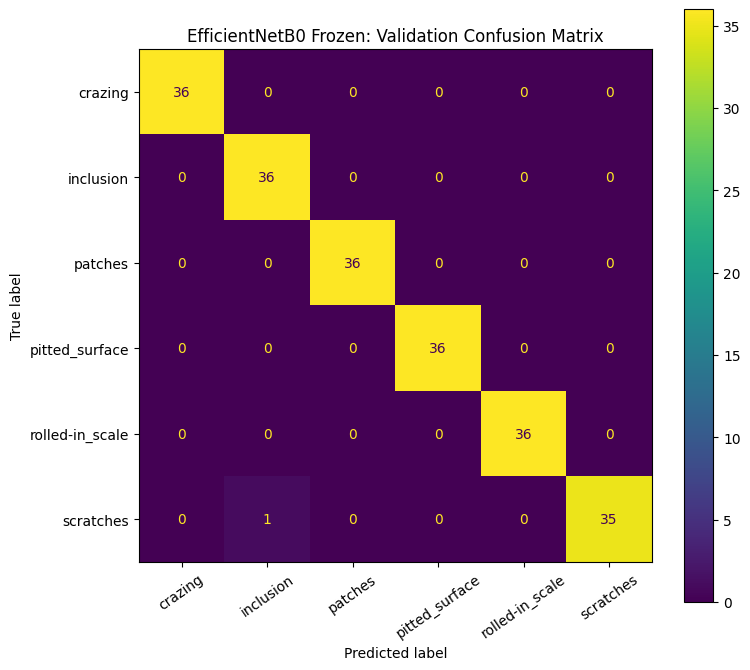

Validation metrics:
validation_accuracy: 0.9954
validation_macro_precision: 0.9955
validation_macro_recall: 0.9954
validation_macro_f1: 0.9954

Logged to MLflow run: d29011c7a09d41c78f6246a9ed185c7b


In [27]:
validation_probabilities_efficientnet = efficientnet_model.predict(
    validation_ds,
    verbose=0,
)

y_pred_efficientnet = np.argmax(
    validation_probabilities_efficientnet,
    axis=1,
)

y_true_efficientnet = np.concatenate(
    [
        batch_labels.numpy()
        for _, batch_labels in validation_ds
    ],
    axis=0,
)

efficientnet_metrics = {
    "validation_accuracy": float(
        accuracy_score(y_true_efficientnet, y_pred_efficientnet)
    ),
    "validation_macro_precision": float(
        precision_score(
            y_true_efficientnet,
            y_pred_efficientnet,
            average="macro",
            zero_division=0,
        )
    ),
    "validation_macro_recall": float(
        recall_score(
            y_true_efficientnet,
            y_pred_efficientnet,
            average="macro",
            zero_division=0,
        )
    ),
    "validation_macro_f1": float(
        f1_score(
            y_true_efficientnet,
            y_pred_efficientnet,
            average="macro",
            zero_division=0,
        )
    ),
}

efficientnet_report_dir = Path("reports/efficientnetb0")
efficientnet_report_dir.mkdir(parents=True, exist_ok=True)

with open(efficientnet_report_dir / "validation_metrics.json", "w") as file:
    json.dump(efficientnet_metrics, file, indent=2)

classification_report_efficientnet = classification_report(
    y_true_efficientnet,
    y_pred_efficientnet,
    target_names=class_names,
    zero_division=0,
    output_dict=True,
)

with open(
    efficientnet_report_dir / "classification_report.json",
    "w",
) as file:
    json.dump(classification_report_efficientnet, file, indent=2)

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_true_efficientnet,
    y_pred_efficientnet,
    display_labels=class_names,
    xticks_rotation=35,
    ax=ax,
)

plt.title("EfficientNetB0 Frozen: Validation Confusion Matrix")
plt.tight_layout()

confusion_matrix_path = (
    efficientnet_report_dir / "validation_confusion_matrix.png"
)

plt.savefig(confusion_matrix_path, dpi=160)
plt.show()

with mlflow.start_run(run_id=efficientnet_run_id):
    mlflow.log_metrics(efficientnet_metrics)

    mlflow.log_artifact(
        str(efficientnet_report_dir / "validation_metrics.json"),
        artifact_path="evaluation",
    )

    mlflow.log_artifact(
        str(efficientnet_report_dir / "classification_report.json"),
        artifact_path="evaluation",
    )

    mlflow.log_artifact(
        str(confusion_matrix_path),
        artifact_path="evaluation",
    )

print("Validation metrics:")
for metric_name, metric_value in efficientnet_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

print("\nLogged to MLflow run:", efficientnet_run_id)

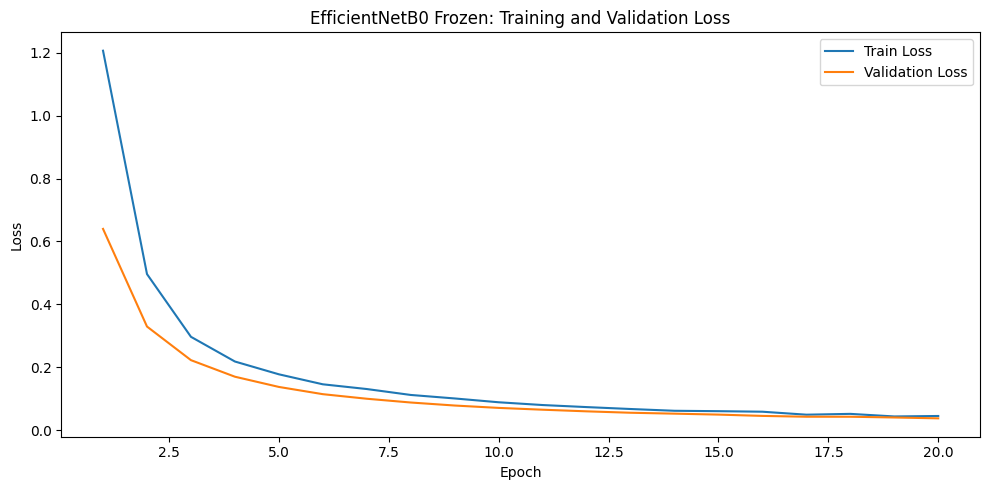

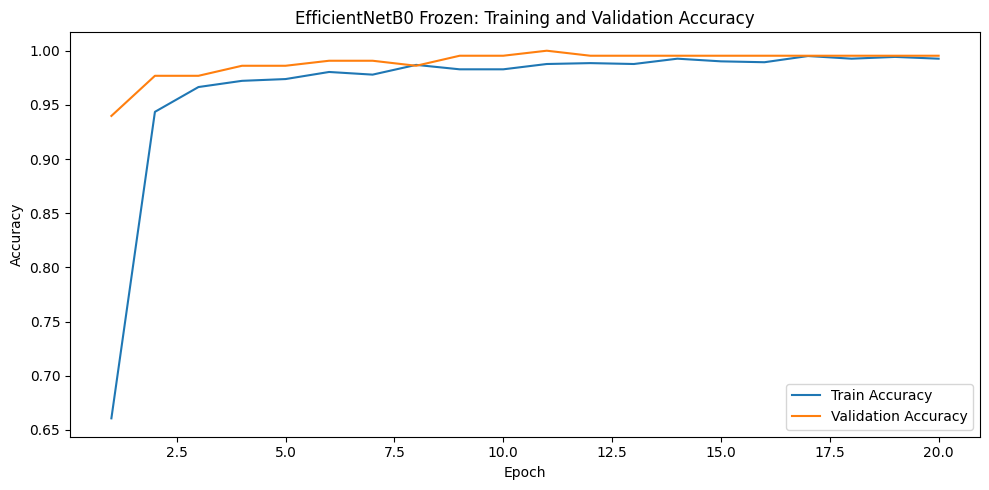

EfficientNetB0 training curves saved and logged to MLflow.


In [28]:
epochs_ran = range(1, len(efficientnet_history.history["loss"]) + 1)

# Loss
plt.figure(figsize=(10, 5))
plt.plot(
    epochs_ran,
    efficientnet_history.history["loss"],
    label="Train Loss",
)
plt.plot(
    epochs_ran,
    efficientnet_history.history["val_loss"],
    label="Validation Loss",
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Frozen: Training and Validation Loss")
plt.legend()
plt.tight_layout()

loss_curve_path = efficientnet_report_dir / "loss_curve.png"
plt.savefig(loss_curve_path, dpi=160)
plt.show()

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(
    epochs_ran,
    efficientnet_history.history["accuracy"],
    label="Train Accuracy",
)
plt.plot(
    epochs_ran,
    efficientnet_history.history["val_accuracy"],
    label="Validation Accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 Frozen: Training and Validation Accuracy")
plt.legend()
plt.tight_layout()

accuracy_curve_path = efficientnet_report_dir / "accuracy_curve.png"
plt.savefig(accuracy_curve_path, dpi=160)
plt.show()

with mlflow.start_run(run_id=efficientnet_run_id):
    mlflow.log_artifact(
        str(loss_curve_path),
        artifact_path="training_curves",
    )
    mlflow.log_artifact(
        str(accuracy_curve_path),
        artifact_path="training_curves",
    )

print("EfficientNetB0 training curves saved and logged to MLflow.")

In [29]:
experiment = mlflow.get_experiment_by_name(
    "surface-defect-classification"
)

runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    output_format="pandas",
)

columns = [
    "tags.mlflow.runName",
    "params.model_name",
    "params.backbone_trainable",
    "params.learning_rate",
    "metrics.validation_accuracy",
    "metrics.validation_macro_precision",
    "metrics.validation_macro_recall",
    "metrics.validation_macro_f1",
    "metrics.best_epoch",
]

comparison_df = (
    runs_df
    .reindex(columns=columns)
    .rename(
        columns={
            "tags.mlflow.runName": "run_name",
            "params.model_name": "model",
            "params.backbone_trainable": "backbone_trainable",
            "params.learning_rate": "learning_rate",
            "metrics.validation_accuracy": "validation_accuracy",
            "metrics.validation_macro_precision": "macro_precision",
            "metrics.validation_macro_recall": "macro_recall",
            "metrics.validation_macro_f1": "macro_f1",
            "metrics.best_epoch": "best_epoch",
        }
    )
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

comparison_df.to_csv(
    "reports/model_comparison_validation.csv",
    index=False,
)

comparison_df

,run_name,model,backbone_trainable,learning_rate,validation_accuracy,macro_precision,macro_recall,macro_f1,best_epoch
0,efficientnetb0-frozen-lr-0.001,EfficientNetB0,False,0.001,0.995370,0.995495,0.995370,0.995369,20.0
1,mobilenetv3small-frozen-lr-0.001,MobileNetV3Small,False,0.001,0.990741,0.991228,0.990741,0.990734,20.0
2,custom-cnn-lr-0.0001-dropout-0.50,custom_cnn_regularized,None,0.0001,0.851852,0.873760,0.851852,0.846118,19.0
3,custom-cnn-lr-0.001-dropout-0.40,custom_cnn_baseline,None,0.001,0.277778,0.097870,0.277778,0.141630,1.0


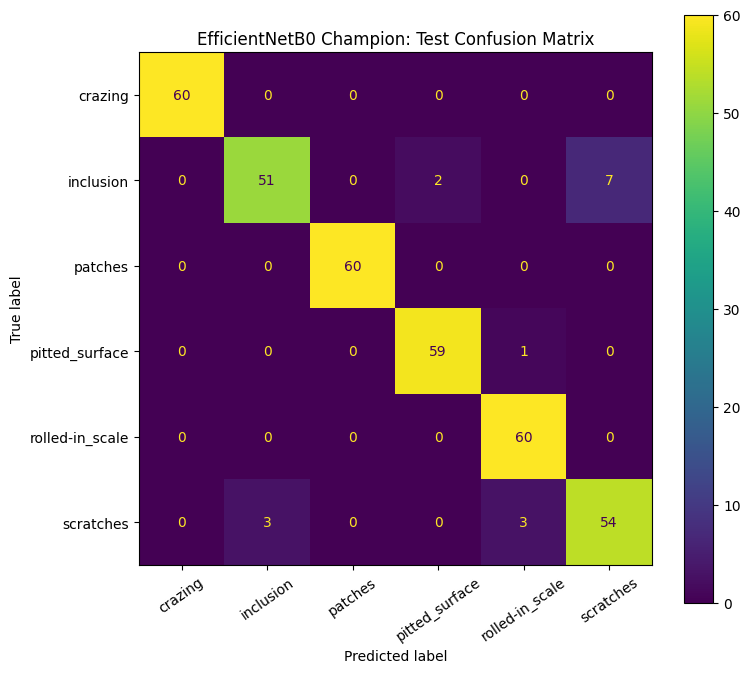

Final test metrics:
test_accuracy: 0.9556
test_macro_precision: 0.9557
test_macro_recall: 0.9556
test_macro_f1: 0.9550
test_total_inference_seconds: 2.0154
test_avg_inference_ms_per_image: 5.5984


In [32]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

# Measure prediction time on the untouched test split
start_time = time.perf_counter()

test_probabilities = efficientnet_model.predict(
    test_ds,
    verbose=0,
)

total_inference_seconds = time.perf_counter() - start_time

y_pred_test = np.argmax(test_probabilities, axis=1)

y_true_test = np.concatenate(
    [batch_labels.numpy() for _, batch_labels in test_ds],
    axis=0,
)

test_metrics = {
    "test_accuracy": float(accuracy_score(y_true_test, y_pred_test)),
    "test_macro_precision": float(
        precision_score(
            y_true_test,
            y_pred_test,
            average="macro",
            zero_division=0,
        )
    ),
    "test_macro_recall": float(
        recall_score(
            y_true_test,
            y_pred_test,
            average="macro",
            zero_division=0,
        )
    ),
    "test_macro_f1": float(
        f1_score(
            y_true_test,
            y_pred_test,
            average="macro",
            zero_division=0,
        )
    ),
    "test_total_inference_seconds": float(total_inference_seconds),
    "test_avg_inference_ms_per_image": float(
        (total_inference_seconds / len(test_df)) * 1000
    ),
}

test_report_dir = Path("reports/champion_efficientnetb0")
test_report_dir.mkdir(parents=True, exist_ok=True)

with open(test_report_dir / "test_metrics.json", "w") as file:
    json.dump(test_metrics, file, indent=2)

test_classification_report = classification_report(
    y_true_test,
    y_pred_test,
    target_names=class_names,
    zero_division=0,
    output_dict=True,
)

with open(test_report_dir / "test_classification_report.json", "w") as file:
    json.dump(test_classification_report, file, indent=2)

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_true_test,
    y_pred_test,
    display_labels=class_names,
    xticks_rotation=35,
    ax=ax,
)

plt.title("EfficientNetB0 Champion: Test Confusion Matrix")
plt.tight_layout()

test_confusion_matrix_path = (
    test_report_dir / "test_confusion_matrix.png"
)

plt.savefig(test_confusion_matrix_path, dpi=160)
plt.show()

with mlflow.start_run(run_id=efficientnet_run_id):
    mlflow.log_metrics(test_metrics)

    mlflow.set_tag("model_selection_status", "champion")

    mlflow.log_artifact(
        str(test_report_dir / "test_metrics.json"),
        artifact_path="test_evaluation",
    )
    mlflow.log_artifact(
        str(test_report_dir / "test_classification_report.json"),
        artifact_path="test_evaluation",
    )
    mlflow.log_artifact(
        str(test_confusion_matrix_path),
        artifact_path="test_evaluation",
    )

print("Final test metrics:")
for name, value in test_metrics.items():
    print(f"{name}: {value:.4f}")

In [33]:
REGISTERED_MODEL_NAME = "SurfaceDefectClassifier"

with mlflow.start_run(run_id=efficientnet_run_id):
    model_info = mlflow.tensorflow.log_model(
        model=efficientnet_model,
        name="efficientnetb0_champion_model",
    )

registered_model = mlflow.register_model(
    model_uri=model_info.model_uri,
    name=REGISTERED_MODEL_NAME,
)

client = mlflow.MlflowClient()

client.set_registered_model_alias(
    name=REGISTERED_MODEL_NAME,
    alias="champion",
    version=registered_model.version,
)

client.set_model_version_tag(
    name=REGISTERED_MODEL_NAME,
    version=registered_model.version,
    key="selection_metric",
    value="validation_macro_f1",
)

client.set_model_version_tag(
    name=REGISTERED_MODEL_NAME,
    version=registered_model.version,
    key="final_test_macro_f1",
    value="0.9550",
)

print("Registered model:", REGISTERED_MODEL_NAME)
print("Version:", registered_model.version)
print("Alias: champion")

2026/07/07 23:05:36 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/07/07 23:05:58 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/07/07 23:05:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/07 23:05:58 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


Registered model: SurfaceDefectClassifier
Version: 1
Alias: champion


Successfully registered model 'SurfaceDefectClassifier'.
Created version '1' of model 'SurfaceDefectClassifier'.


In [34]:



backup_root = Path(
    "/content/drive/MyDrive/surface-scan-mlops/final_model_selection"
)
backup_root.mkdir(parents=True, exist_ok=True)

items_to_backup = [
    Path("/content/mlflow.db"),
    Path("/content/mlartifacts"),
    Path("artifacts"),
    Path("reports"),
]

for source in items_to_backup:
    if not source.exists():
        print(f"Skipped missing: {source}")
        continue

    destination = backup_root / source.name

    if destination.exists():
        if destination.is_dir():
            shutil.rmtree(destination)
        else:
            destination.unlink()

    if source.is_dir():
        shutil.copytree(source, destination)
    else:
        shutil.copy2(source, destination)

    print(f"Backed up: {source} → {destination}")

print("\nFinal backup complete.")

Backed up: /content/mlflow.db → /content/drive/MyDrive/surface-scan-mlops/final_model_selection/mlflow.db
Backed up: /content/mlartifacts → /content/drive/MyDrive/surface-scan-mlops/final_model_selection/mlartifacts
Backed up: artifacts → /content/drive/MyDrive/surface-scan-mlops/final_model_selection/artifacts
Backed up: reports → /content/drive/MyDrive/surface-scan-mlops/final_model_selection/reports

Final backup complete.
